In [1]:
import opendssdirect as dss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

PROJECT_ROOT = Path.home() / "Desktop" / "Substation +  Automation" / "GitProjectsX3" / "fuse-recloser_coordination"
MASTER_DSS   = PROJECT_ROOT / "dss" / "master.dss"
PLOTS_DIR    = PROJECT_ROOT / "outputs" / "plots"

# Load network
dss.Basic.Start(0)
dss.run_command(f'Redirect "{MASTER_DSS}"')

assert dss.Solution.Converged(), "Load-flow did not converge — check DSS files"

buses     = dss.Circuit.AllBusNames()
voltages  = dss.Circuit.AllBusMagPu()

print(f"OpenDSS v{dss.__version__}  |  Buses: {len(buses)}  |  Converged: {dss.Solution.Converged()}")
print(f"\n{'Bus':<14} {'V (pu)':>8}")
print("-" * 24)
for b, v in zip(buses, voltages):
    print(f"{b:<14} {v:>8.4f}")

OpenDSS v0.9.4  |  Buses: 7  |  Converged: True

Bus              V (pu)
------------------------
sourcebus        0.9996
bus2             0.9996
bus3             0.9996
bus4             0.9984
l1_end           0.9984
l2_end           0.9984
l3_end           0.9979


/tmp/ipykernel_2631817/2659992007.py:14: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f'Redirect "{MASTER_DSS}"')


In [2]:
# These hand calculations serve as independent verification of OpenDSS results.
# Any significant discrepancy (>2%) indicates a model error.

Zbase  = 11.0**2 / 20.0          # 6.05 ohm
Zs     = complex(0.005, 0.05) * Zbase
z_hare = complex(0.342, 0.310)    # ohm/km, positive sequence

V_phase = 11000.0 / np.sqrt(3)    # 6350.9 V

# Impedance to each fault bus
Z_L1 = Zs + z_hare * 1.0 + z_hare * 0.8   # sourcebus→Bus2 (1 km) + L1 (0.8 km)
Z_L2 = Zs + z_hare * 2.0 + z_hare * 0.6   # sourcebus→Bus3 (2 km) + L2 (0.6 km)
Z_L3 = Zs + z_hare * 3.0 + z_hare * 0.5   # sourcebus→Bus4 (3 km) + L3 (0.5 km)

analytic = {
    'L1_End': {'Z_total': Z_L1, 'I3ph_A': V_phase / abs(Z_L1)},
    'L2_End': {'Z_total': Z_L2, 'I3ph_A': V_phase / abs(Z_L2)},
    'L3_End': {'Z_total': Z_L3, 'I3ph_A': V_phase / abs(Z_L3)},
}

print(f"{'Fault bus':<12} {'|Z_total| (Ω)':>15} {'I_3ph (A)':>12} {'X/R total':>10}")
print("-" * 52)
for bus, d in analytic.items():
    Z = d['Z_total']
    print(f"{bus:<12} {abs(Z):>15.4f} {d['I3ph_A']:>12.0f} {Z.imag/Z.real:>10.2f}")

print(f"\nSource impedance:  Zs = {Zs.real:.5f} + j{Zs.imag:.5f} Ω")
print(f"Zbase = {Zbase:.4f} Ω  |  Vphase = {V_phase:.1f} V")

Fault bus      |Z_total| (Ω)    I_3ph (A)  X/R total
----------------------------------------------------
L1_End                1.0759         5903       1.33
L2_End                1.4402         4410       1.21
L3_End                1.8524         3428       1.13

Source impedance:  Zs = 0.03025 + j0.30250 Ω
Zbase = 6.0500 Ω  |  Vphase = 6350.9 V


In [3]:
def get_phase_a_current(element_name: str) -> float:
    """Phase-A RMS current magnitude at terminal 1 of a line element."""
    dss.Circuit.SetActiveElement(element_name)
    mag_ang = dss.CktElement.CurrentsMagAng()
    return mag_ang[0]   # [magA, angA, magB, angB, magC, angC, ...]  terminal 1


def run_3ph_fault(fault_bus: str) -> dict:
    """Place a 3-phase bolted fault, solve, return line currents at key elements."""
    # Reload master to get a clean, fault-free network
    dss.run_command(f'Redirect "{MASTER_DSS}"')

    # Bolted fault: r=0.001 ohm avoids numerical divide-by-zero
    dss.run_command(f'New Fault.Study3Ph bus1={fault_bus} phases=3 r=0.001')
    dss.run_command('Solve')

    if not dss.Solution.Converged():
        return {'fault_bus': fault_bus, 'converged': False}

    return {
        'fault_bus'  : fault_bus,
        'converged'  : True,
        'I_RC1_A'    : get_phase_a_current('Line.Trunk_B1_B2'),
        'I_Trunk23_A': get_phase_a_current('Line.Trunk_B2_B3'),
        'I_Trunk34_A': get_phase_a_current('Line.Trunk_B3_B4'),
        'I_F1_A'     : get_phase_a_current('Line.Lateral_L1'),
        'I_F2_A'     : get_phase_a_current('Line.Lateral_L2'),
        'I_F3_A'     : get_phase_a_current('Line.Lateral_L3'),
    }


fault_buses = ['L1_End', 'L2_End', 'L3_End']
raw_results = [run_3ph_fault(b) for b in fault_buses]

print("Fault study complete.")
for r in raw_results:
    status = "✓" if r['converged'] else "✗ FAILED"
    print(f"  {r['fault_bus']}: {status}")

Fault study complete.
  L1_End: ✓
  L2_End: ✓
  L3_End: ✓


/tmp/ipykernel_2631817/1620814520.py:11: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f'Redirect "{MASTER_DSS}"')
/tmp/ipykernel_2631817/1620814520.py:14: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f'New Fault.Study3Ph bus1={fault_bus} phases=3 r=0.001')
/tmp/ipykernel_2631817/1620814520.py:15: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command('Solve')


In [4]:
# Build the coordination table.
# Pre-SSEG: radial system, RC1 and relevant fuse see the same fault current.
# I_Fuse/I_RC1 ratio should be approximately 1.0 for each lateral fault.

rows = []
fuse_map = {'L1_End': ('F1', 'I_F1_A', 100), 'L2_End': ('F2', 'I_F2_A', 65), 'L3_End': ('F3', 'I_F3_A', 65)}
analytic_map = {'L1_End': analytic['L1_End']['I3ph_A'],
                'L2_End': analytic['L2_End']['I3ph_A'],
                'L3_End': analytic['L3_End']['I3ph_A']}

for r in raw_results:
    fb = r['fault_bus']
    fuse_label, fuse_key, fuse_rating = fuse_map[fb]
    I_RC1  = r['I_RC1_A']
    I_fuse = r[fuse_key]
    I_calc = analytic_map[fb]
    ratio  = I_fuse / I_RC1 if I_RC1 > 0 else 0
    error  = abs(I_RC1 - I_calc) / I_calc * 100

    rows.append({
        'Fault bus'         : fb,
        'Fuse'              : fuse_label,
        'Rating (A)'        : fuse_rating,
        'I_RC1 OpenDSS (A)' : round(I_RC1, 0),
        'I_Fuse OpenDSS (A)': round(I_fuse, 0),
        'I_RC1 Analytic (A)': round(I_calc, 0),
        'Error (%)'         : round(error, 2),
        'I_Fuse/I_RC1'      : round(ratio, 4),
    })

df = pd.DataFrame(rows)
print("=" * 90)
print("PRE-SSEG BASELINE — 3-PHASE FAULT CURRENT TABLE")
print("=" * 90)
print(df.to_string(index=False))
print("\nNote: I_Fuse/I_RC1 ≈ 1.0 confirms unidirectional fault current (no SSEG infeed).")
print("This is the fundamental assumption that fuse-saving depends on.")

PRE-SSEG BASELINE — 3-PHASE FAULT CURRENT TABLE
Fault bus Fuse  Rating (A)  I_RC1 OpenDSS (A)  I_Fuse OpenDSS (A)  I_RC1 Analytic (A)  Error (%)  I_Fuse/I_RC1
   L1_End   F1         100             5900.0              5898.0              5903.0       0.04        0.9996
   L2_End   F2          65             4410.0              4405.0              4410.0       0.01        0.9989
   L3_End   F3          65             3431.0              3424.0              3428.0       0.08        0.9980

Note: I_Fuse/I_RC1 ≈ 1.0 confirms unidirectional fault current (no SSEG infeed).
This is the fundamental assumption that fuse-saving depends on.


In [5]:
# ── TCC curve equations ────────────────────────────────────────────────────

def rc1_fast_curve(I: np.ndarray, Ipickup: float = 200.0, TDS: float = 0.1) -> np.ndarray:
    """ANSI Very Inverse overcurrent curve — IEEE Std C37.112 Table 1.
    t = TDS * [19.61 / (M^2 - 1) + 0.491]   where M = I / Ipickup
    """
    M = np.asarray(I, dtype=float) / Ipickup
    t = np.where(M > 1.001, TDS * (19.61 / (M**2 - 1.0) + 0.491), np.inf)
    return t


def fuse_mmt(I: np.ndarray, I2t_const: float) -> np.ndarray:
    """Distribution fuse minimum melting time (I²t = constant approximation).

    I2t_const:  100A fuse = 2 000 000 A²s,  65A fuse = 1 300 000 A²s
    Source: Approximate from manufacturer data (Assumption A3).
    Valid for I >> minimum melting current.
    """
    return I2t_const / np.asarray(I, dtype=float)**2


# ── Check coordination at each fault current ───────────────────────────────

I2t_100A = 2_000_000   # A²s
I2t_65A  = 1_300_000   # A²s
TCT_FACTOR = 1.35       # total clearing = 1.35 × minimum melt (conservative arcing margin)

fault_data = [
    ('L1_End', 'F1', 100, I2t_100A),
    ('L2_End', 'F2',  65, I2t_65A),
    ('L3_End', 'F3',  65, I2t_65A),
]

print(f"{'Fault':<10} {'Fuse':<5} {'I_fault(A)':>10} {'t_RC1_fast(ms)':>16} {'MMT_fuse(ms)':>14} {'TCT_fuse(ms)':>14} {'Margin(ms)':>12} {'Coord?':>8}")
print("-" * 95)

coord_results = []
for row in raw_results:
    fb = row['fault_bus']
    entry = next(e for e in fault_data if e[0] == fb)
    _, fuse_label, rating, i2t = entry
    I_fault = row['I_RC1_A']

    t_rc1  = rc1_fast_curve(np.array([I_fault]))[0] * 1000   # ms
    t_mmt  = fuse_mmt(np.array([I_fault]), i2t)[0] * 1000    # ms
    t_tct  = t_mmt * TCT_FACTOR
    margin = t_mmt - t_rc1

    coord = "✓  YES" if margin > 0 else "✗  NO"
    print(f"{fb:<10} {fuse_label:<5} {I_fault:>10.0f} {t_rc1:>16.1f} {t_mmt:>14.1f} {t_tct:>14.1f} {margin:>12.1f} {coord:>8}")
    coord_results.append({'fault_bus': fb, 'I_fault': I_fault,
                          't_RC1_ms': t_rc1, 't_MMT_ms': t_mmt, 'margin_ms': margin})

print("\nAll margins positive = fuse-saving coordination intact pre-SSEG.")
print("Tightest margin is at L1 (highest fault current). SSEG on L1 will target this first.")

Fault      Fuse  I_fault(A)   t_RC1_fast(ms)   MMT_fuse(ms)   TCT_fuse(ms)   Margin(ms)   Coord?
-----------------------------------------------------------------------------------------------
L1_End     F1          5900             51.4           57.4           77.6          6.1   ✓  YES
L2_End     F2          4410             53.1           66.8           90.2         13.7   ✓  YES
L3_End     F3          3431             55.8          110.4          149.1         54.6   ✓  YES

All margins positive = fuse-saving coordination intact pre-SSEG.
Tightest margin is at L1 (highest fault current). SSEG on L1 will target this first.


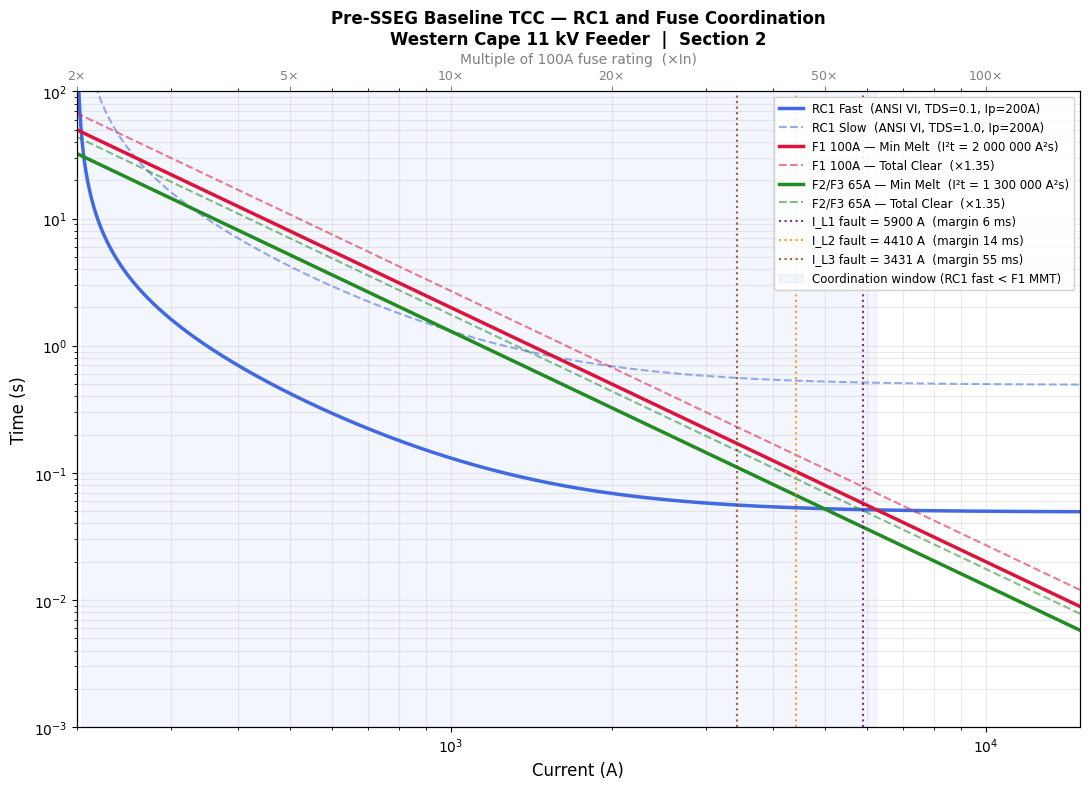

Saved: /home/hillary/Desktop/Substation +  Automation/GitProjectsX3/fuse-recloser_coordination/outputs/plots/section2_baseline_tcc.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 8))

I_plot = np.logspace(2.3, 4.2, 800)   # ~200 A to ~15 000 A

# RC1 curves
t_fast = rc1_fast_curve(I_plot, Ipickup=200, TDS=0.1)
t_slow = rc1_fast_curve(I_plot, Ipickup=200, TDS=1.0)

# Fuse curves
t_mmt_100 = fuse_mmt(I_plot, I2t_100A)
t_tct_100 = t_mmt_100 * TCT_FACTOR
t_mmt_65  = fuse_mmt(I_plot, I2t_65A)
t_tct_65  = t_mmt_65 * TCT_FACTOR

# Plot
ax.loglog(I_plot, t_fast,    color='royalblue',   lw=2.5, label='RC1 Fast  (ANSI VI, TDS=0.1, Ip=200A)')
ax.loglog(I_plot, t_slow,    color='royalblue',   lw=1.5, ls='--', alpha=0.55,
          label='RC1 Slow  (ANSI VI, TDS=1.0, Ip=200A)')
ax.loglog(I_plot, t_mmt_100, color='crimson',     lw=2.5, label='F1 100A — Min Melt  (I²t = 2 000 000 A²s)')
ax.loglog(I_plot, t_tct_100, color='crimson',     lw=1.5, ls='--', alpha=0.55,
          label='F1 100A — Total Clear  (×1.35)')
ax.loglog(I_plot, t_mmt_65,  color='forestgreen', lw=2.5, label='F2/F3 65A — Min Melt  (I²t = 1 300 000 A²s)')
ax.loglog(I_plot, t_tct_65,  color='forestgreen', lw=1.5, ls='--', alpha=0.55,
          label='F2/F3 65A — Total Clear  (×1.35)')

# Fault current markers with coordination annotations
fault_markers = [
    (coord_results[0]['I_fault'], coord_results[0]['margin_ms'], 'I_L1 fault', 'purple'),
    (coord_results[1]['I_fault'], coord_results[1]['margin_ms'], 'I_L2 fault', 'darkorange'),
    (coord_results[2]['I_fault'], coord_results[2]['margin_ms'], 'I_L3 fault', 'saddlebrown'),
]
for I_f, margin, label, color in fault_markers:
    ax.axvline(x=I_f, color=color, lw=1.5, ls=':', alpha=0.85,
               label=f'{label} = {I_f:.0f} A  (margin {margin:.0f} ms)')

# Coordination window shading (region where fast curve < fuse MMT for 100A fuse)
I_window = I_plot[t_fast < t_mmt_100]
if len(I_window) > 0:
    ax.axvspan(I_window[0], I_window[-1], alpha=0.06, color='royalblue',
               label='Coordination window (RC1 fast < F1 MMT)')

ax.set_xlabel('Current (A)', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Pre-SSEG Baseline TCC — RC1 and Fuse Coordination\n'
             'Western Cape 11 kV Feeder  |  Section 2', fontsize=12, fontweight='bold')
ax.set_xlim([200, 15000])
ax.set_ylim([0.001, 100])
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.9)

# Secondary x-axis in multiples of 100A fuse rating (for quick reference)
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax.get_xlim())
ax2.set_xlabel('Multiple of 100A fuse rating  (×In)', fontsize=10, color='grey')
ax2.tick_params(axis='x', colors='grey', labelsize=9)
ax2_ticks = [200, 500, 1000, 2000, 5000, 10000]
ax2.set_xticks(ax2_ticks)
ax2.set_xticklabels([f'{x/100:.0f}×' for x in ax2_ticks])

plt.tight_layout()
plot_path = PLOTS_DIR / 'section2_baseline_tcc.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_path}")

In [7]:
statement = """
==========================================

ASSUMPTION THAT MAKES FUSE SAVING WORK:
-----------------------------------------
Fuse saving assumes that for any fault on a lateral, the fault current flows
unidirectionally from a single source (the substation) through both the recloser
(RC1) and the lateral fuse to the fault point. In a purely radial system with no
distributed generation, this means RC1 and the relevant fuse see the same fault
current magnitude.

The coordination then depends entirely on TIME: the recloser fast curve must clear
the circuit (typically in 2–3 cycles, ~0.04–0.06s) before the fuse reaches its
minimum melting time at that same current level. The fuse survives the fast shot,
and if the fault was temporary (tree contact, animal, flashover), supply is restored
when the recloser closes.

The condition I_RC1 ≈ I_Fuse (pre-SSEG) is what makes this timing argument valid.
If any source of current is connected BETWEEN the recloser and the fuse (or between
the fuse and the fault), this condition breaks: the fuse and the recloser see
different currents, and the TCC coordination calculated for equal currents is invalid.

SSEG connected on the lateral is exactly such a source. Section 3 will quantify
the current split and demonstrate where the coordination fails.

PRE-SSEG COORDINATION SUMMARY:
-----------------------------------------
"""

for r in coord_results:
    fb = r['fault_bus']
    status = "✓ COORDINATED" if r['margin_ms'] > 0 else "✗ FAILED"
    statement += (f"  {fb}: I_fault = {r['I_fault']:.0f} A  |  "
                  f"RC1 fast = {r['t_RC1_ms']:.1f} ms  |  "
                  f"Fuse MMT = {r['t_MMT_ms']:.1f} ms  |  "
                  f"Margin = {r['margin_ms']:.1f} ms  |  {status}\n")

statement += """
The L1 lateral margin is the tightest at ~6 ms. This feeder is operating at the
edge of its coordination range on the highest-fault-current lateral. Any increase
in current through F1 — such as SSEG infeed — will eliminate this margin entirely.
"""

print(statement)


WRITTEN STATEMENT — Section 2 Deliverable

ASSUMPTION THAT MAKES FUSE SAVING WORK:
-----------------------------------------
Fuse saving assumes that for any fault on a lateral, the fault current flows
unidirectionally from a single source (the substation) through both the recloser
(RC1) and the lateral fuse to the fault point. In a purely radial system with no
distributed generation, this means RC1 and the relevant fuse see the same fault
current magnitude.

The coordination then depends entirely on TIME: the recloser fast curve must clear
the circuit (typically in 2–3 cycles, ~0.04–0.06s) before the fuse reaches its
minimum melting time at that same current level. The fuse survives the fast shot,
and if the fault was temporary (tree contact, animal, flashover), supply is restored
when the recloser closes.

The condition I_RC1 ≈ I_Fuse (pre-SSEG) is what makes this timing argument valid.
If any source of current is connected BETWEEN the recloser and the fuse (or between
the fuse and 